# Fase 3 — busca de hiperparâmetros (Optuna), leva 1

Busca via Optuna em MLP e Gradient Boosting — os dois baselines que já
deram resultado estável na Fase 2. Cada trial otimiza **KS na validação**;
o teste só é tocado uma vez no final, para reportar a métrica honesta do
modelo vencedor de cada leva (nunca usado para escolher hiperparâmetro).

Nota de ambiente: o storage SQLite nativo do Optuna falha com erro de I/O
de disco quando o arquivo `.db` fica num drive de rede montado (é o caso
da pasta do usuário aqui) — SQLite precisa de locking de arquivo que esse
tipo de mount não garante. Cada estudo roda em memória e os trials são
exportados para CSV (`reports/tables/fase3_trials_*.csv`) — suficiente
para inspecionar e comparar levas sem depender de retomar via SQLite.


In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from churn_telecom.checkpointing import load_all_metadata

sns.set_theme(style="whitegrid")


## 1. Trials da leva 1 — MLP

In [2]:
trials_mlp = pd.read_csv(ROOT / "reports/tables/fase3_trials_mlp_leva1.csv")
trials_mlp[["number", "value", "params_n_camadas", "params_n_unidades", "params_activation",
            "params_solver", "params_learning_rate_init", "params_alpha", "params_loss_metric"]].sort_values("value", ascending=False).head(10)


,number,value,params_n_camadas,params_n_unidades,params_activation,params_solver,params_learning_rate_init,params_alpha,params_loss_metric
16,16,0.549459,2,40,tanh,adam,0.079577,0.000253,mse
9,9,0.540185,2,40,tanh,adam,0.091091,0.000001,mse
4,4,0.537094,2,10,tanh,sgd,0.000147,0.007160,mse
12,12,0.537094,2,10,tanh,sgd,0.000912,0.012433,mse
3,3,0.536321,2,40,logistic,sgd,0.031819,0.000003,cross_entropy
5,5,0.536321,1,40,logistic,sgd,0.000342,0.021877,mse
14,14,0.536321,2,10,tanh,sgd,0.001174,0.000027,mse
8,8,0.535549,1,40,relu,adam,0.096213,0.008839,cross_entropy
7,7,0.534003,2,20,logistic,adam,0.000253,0.000059,mse
6,6,0.532457,1,20,tanh,sgd,0.001990,0.000004,cross_entropy


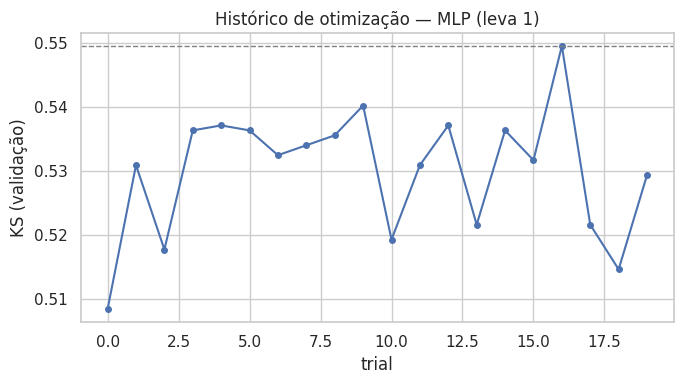

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(trials_mlp["number"], trials_mlp["value"], marker="o", ms=4)
ax.axhline(trials_mlp["value"].cummax().iloc[-1], ls="--", color="gray", lw=1)
ax.set_xlabel("trial")
ax.set_ylabel("KS (validação)")
ax.set_title("Histórico de otimização — MLP (leva 1)")
plt.tight_layout()
fig.savefig(ROOT / "reports/figures/fase3_mlp_historico_otimizacao.png", dpi=120)
plt.show()


## 2. Trials da leva 1 — Gradient Boosting

In [4]:
trials_gb = pd.read_csv(ROOT / "reports/tables/fase3_trials_gb_leva1.csv")
trials_gb[["number", "value", "params_learning_rate", "params_n_estimators",
           "params_subsample", "params_min_samples_leaf", "params_max_depth"]].sort_values("value", ascending=False).head(10)


,number,value,params_learning_rate,params_n_estimators,params_subsample,params_min_samples_leaf,params_max_depth
14,14,0.571097,0.037502,202,0.503722,34,2
19,19,0.564142,0.027323,234,0.688518,31,2
6,6,0.563369,0.027253,168,0.655512,45,2
7,7,0.560278,0.044134,85,0.927488,43,2
18,18,0.560278,0.014147,236,0.511748,34,2
12,12,0.558733,0.035383,116,0.604369,44,2
15,15,0.557960,0.085018,176,0.651870,29,2
0,0,0.557960,0.015209,193,0.694013,45,3
8,8,0.554096,0.025387,106,0.974855,25,4
17,17,0.554096,0.031370,201,0.574740,37,3


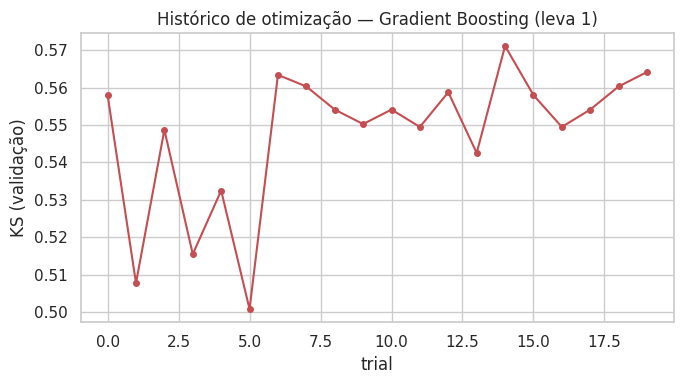

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(trials_gb["number"], trials_gb["value"], marker="o", ms=4, color="#C44E52")
ax.set_xlabel("trial")
ax.set_ylabel("KS (validação)")
ax.set_title("Histórico de otimização — Gradient Boosting (leva 1)")
plt.tight_layout()
fig.savefig(ROOT / "reports/figures/fase3_gb_historico_otimizacao.png", dpi=120)
plt.show()


## 3. Comparação com os baselines da Fase 2

Resultado honesto no **teste** (nunca usado na busca) — compara os modelos
otimizados contra os baselines de hiperparâmetros padrão.

In [6]:
resumo = load_all_metadata(ROOT / "results")
cols_mostrar = ["model_id", "metrics.ks", "metrics.auroc", "metrics.recall", "metrics.precision"]
cols_existentes = [c for c in cols_mostrar if c in resumo.columns]
tabela = resumo[cols_existentes].sort_values("metrics.ks", ascending=False).reset_index(drop=True)
tabela


,model_id,metrics.ks,metrics.auroc,metrics.recall,metrics.precision
0,gb_churn_baseline_oversample,0.524183,0.831954,0.743590,0.532110
1,xgb_churn_baseline_oversample,0.519855,0.831416,0.752137,0.528529
2,gb_churn_baseline_classweight,0.512136,0.831246,0.758547,0.512266
3,mlp_churn_baseline_oversample,0.511046,0.829421,0.767094,0.493132
4,mlp_churn_optuna_leva1,0.510758,0.816685,0.724359,0.544141
5,gb_churn_optuna_leva1,0.510391,0.835575,0.756410,0.513043
6,xgb_churn_baseline_scaleposweight,0.509767,0.833499,0.767094,0.515805


## 4. Achado honesto: o gap entre validação e teste

O melhor trial de Gradient Boosting chegou a **KS=0.571 na validação**, bem
acima dos ~0.52 dos baselines — mas, retreinado e avaliado no teste, caiu
para **KS≈0.510**, ficando basicamente empatado com o baseline simples. O
mesmo padrão (mais discreto) aparece no MLP: KS=0.5495 na validação vira
KS≈0.511 no teste.

Isso é overfitting de hiperparâmetro — com poucos trials (20) e um único
split fixo de validação, o Optuna pode encontrar uma combinação que
"acerta" ruído específico da validação, sem generalizar. É exatamente o
tipo de resultado bom demais que a disciplina deste projeto pede para
auditar antes de aceitar — e, auditado, a conclusão honesta é que **a
busca de hiperparâmetros desta leva não trouxe ganho real sobre os
baselines da Fase 2** no conjunto de teste.

In [7]:
comparacao_val_teste = pd.DataFrame([
    {"modelo": "MLP", "melhor_ks_validacao": float(trials_mlp["value"].max()),
     "ks_teste_do_vencedor": float(resumo.loc[resumo["model_id"] == "mlp_churn_optuna_leva1", "metrics.ks"].iloc[0])},
    {"modelo": "Gradient Boosting", "melhor_ks_validacao": float(trials_gb["value"].max()),
     "ks_teste_do_vencedor": float(resumo.loc[resumo["model_id"] == "gb_churn_optuna_leva1", "metrics.ks"].iloc[0])},
])
comparacao_val_teste["gap"] = comparacao_val_teste["melhor_ks_validacao"] - comparacao_val_teste["ks_teste_do_vencedor"]
comparacao_val_teste


,modelo,melhor_ks_validacao,ks_teste_do_vencedor,gap
0,MLP,0.549459,0.510758,0.038701
1,Gradient Boosting,0.571097,0.510391,0.060706


## 5. Resumo e próximos passos

- Leva 1 de busca Optuna (20 trials cada) não superou os baselines de
  hiperparâmetros padrão da Fase 2 no teste — o ganho visto na validação
  não generalizou.
- Isso sugere que, para esta leva, o espaço de busca já estava próximo do
  ótimo acessível com a reponderação/oversampling atual, ou que o ruído de
  um único split de validação é grande demais para 20 trials distinguirem
  configurações de fato melhores.
- Possíveis próximos passos para uma leva 2 (não executados aqui): usar
  validação cruzada em vez de um único split fixo para a métrica do
  Optuna, ou ampliar o número de trials — mas o ganho esperado é
  incerto dado o resultado desta leva.
- Seguindo para a Fase 4 (engenharia de features) com o entendimento de
  que os baselines da Fase 2 continuam sendo a referência mais honesta até
  agora (KS≈0.51–0.52 no teste).
